# E-Commerce Sales Performance Analysis

## Business Problem

A rapidly growing e-commerce company wants to better understand its sales performance, customer behavior, and product trends across different regions. The company has accumulated large amounts of transaction data but lacks clear insights into which products, customers, and geographic areas contribute the most to business success.

## Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Olist Brazilian E-Commerce dataset and generate actionable business insights that support data-driven decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
customers = pd.read_csv("Dataset/olist_customers_dataset.csv")
orders = pd.read_csv("Dataset/olist_orders_dataset.csv")
order_items = pd.read_csv("Dataset/olist_order_items_dataset.csv")
products = pd.read_csv("Dataset/olist_products_dataset.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)


In [4]:
print("Customers Columns:")
print(customers.columns)

print("\nOrders Columns:")
print(orders.columns)

print("\nOrder Items Columns:")
print(order_items.columns)

print("\nProducts Columns:")
print(products.columns)

Customers Columns:
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

Orders Columns:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

Order Items Columns:
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

Products Columns:
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')


In [5]:
print("Customers Missing Values")
print(customers.isnull().sum())

print("\nOrders Missing Values")
print(orders.isnull().sum())

print("\nOrder Items Missing Values")
print(order_items.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())

Customers Missing Values
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders Missing Values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Items Missing Values
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products Missing Values
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm          

# Data Cleaning Notes

## Missing Values Identified

### Orders Dataset
- order_approved_at : 160 missing values
- order_delivered_carrier_date : 1783 missing values
- order_delivered_customer_date : 2965 missing values

Reason:
These missing values are likely caused by cancelled, unavailable, or undelivered orders.

### Products Dataset
- product_length_cm : 2 missing values
- product_height_cm : 2 missing values
- product_width_cm : 2 missing values

Action:
The missing product dimensions will be filled using the median values of their respective columns.

In [6]:
category_translation = pd.read_csv(
    "Dataset/product_category_name_translation.csv"
)

category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [7]:
products_category = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_category.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [8]:
sales = order_items.merge(
    products_category,
    on="product_id",
    how="left"
)

sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [9]:
sales["revenue"] = (
    sales["price"] +
    sales["freight_value"]
)

sales[["price", "freight_value", "revenue"]].head()

,price,freight_value,revenue
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [10]:
category_revenue = (
    sales.groupby(
        "product_category_name_english"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

category_revenue.head(10)

product_category_name_english
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
furniture_decor           902511.79
housewares                778397.77
cool_stuff                719329.95
auto                      685384.32
garden_tools              584219.21
Name: revenue, dtype: float64

In [11]:
customers = pd.read_csv("Dataset/olist_customers_dataset.csv")
orders = pd.read_csv("Dataset/olist_orders_dataset.csv")
order_items = pd.read_csv("Dataset/olist_order_items_dataset.csv")
products = pd.read_csv("Dataset/olist_products_dataset.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [12]:
category_translation = pd.read_csv(
    "Dataset/product_category_name_translation.csv"
)

print("Category Translation Loaded")

Category Translation Loaded


In [13]:
products_category = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_category.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [14]:
products_category = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_category.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [15]:
sales = order_items.merge(
    products_category,
    on="product_id",
    how="left"
)

sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [16]:
sales["revenue"] = (
    sales["price"] +
    sales["freight_value"]
)

sales[["price", "freight_value", "revenue"]].head()

,price,freight_value,revenue
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [17]:
category_revenue = (
    sales.groupby(
        "product_category_name_english"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

category_revenue.head(10)

product_category_name_english
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
furniture_decor           902511.79
housewares                778397.77
cool_stuff                719329.95
auto                      685384.32
garden_tools              584219.21
Name: revenue, dtype: float64

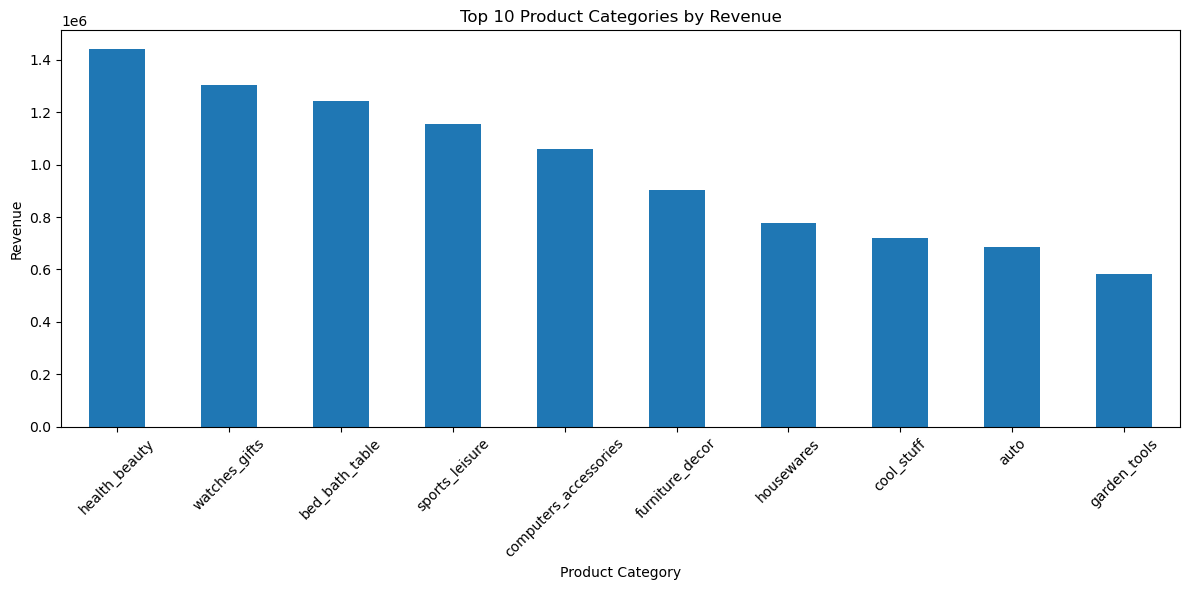

In [18]:
top10_categories = category_revenue.head(10)

plt.figure(figsize=(12,6))

top10_categories.plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Business Insight

The Health & Beauty category generated the highest revenue, followed by Watches & Gifts and Bed Bath Table products.

These categories contribute a significant share of total sales and should be prioritized for:
- Marketing campaigns
- Inventory planning
- Promotional offers

Investing more resources into high-performing categories can help maximize revenue growth and customer engagement.

In [19]:
sales_region = sales.merge(
    orders[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

sales_region = sales_region.merge(
    customers[
        [
            "customer_id",
            "customer_city",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left"
)

sales_region.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,revenue,customer_id,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,72.19,3ce436f183e68e07877b285a838db11a,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,259.83,f6dd3ec061db4e3987629fe6b26e5cce,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,216.87,6489ae5e4333f3693df5ad4372dab6d3,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,25.78,d4eb9395c8c0431ee92fce09860c5a06,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,218.04,58dbd0b2d70206bf40e62cd34e84d795,varzea paulista,SP


In [20]:
state_revenue = (
    sales_region.groupby(
        "customer_state"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

state_revenue.head(10)

customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: revenue, dtype: float64

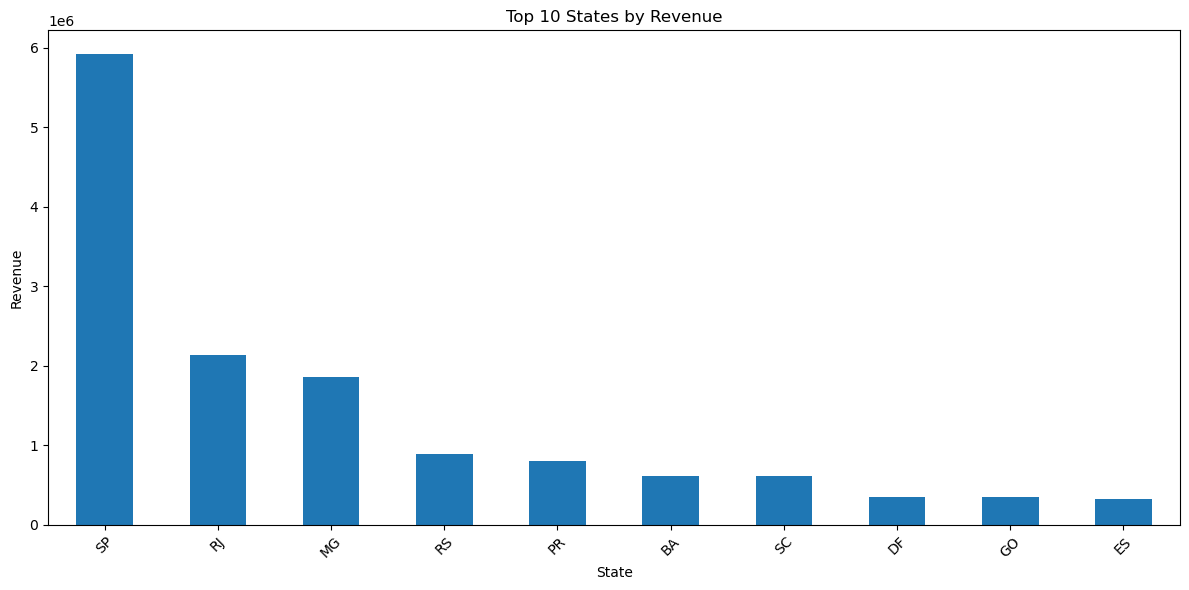

In [21]:
plt.figure(figsize=(12,6))

state_revenue.head(10).plot(
    kind="bar"
)

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Geographic Performance Insight

The analysis shows that a small number of states contribute the majority of revenue.

States with the highest revenue represent the company's strongest markets and should receive continued investment through targeted marketing campaigns, faster delivery services, and customer retention programs.

Lower-performing regions may present growth opportunities through localized promotions and improved logistics support.

In [22]:
customer_revenue = (
    sales_region.groupby(
        "customer_id"
    )["revenue"]
    .sum()
    .reset_index()
)

customer_revenue.head()

,customer_id,revenue
0,00012a2ce6f8dcda20d059ce98491703,114.74
1,000161a058600d5901f007fab4c27140,67.41
2,0001fd6190edaaf884bcaf3d49edf079,195.42
3,0002414f95344307404f0ace7a26f1d5,179.35
4,000379cdec625522490c315e70c7a9fb,107.01


In [23]:
customer_revenue["segment"] = pd.qcut(
    customer_revenue["revenue"],
    q=3,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ]
)

customer_revenue.head()

,customer_id,revenue,segment
0,00012a2ce6f8dcda20d059ce98491703,114.74,Medium Value
1,000161a058600d5901f007fab4c27140,67.41,Low Value
2,0001fd6190edaaf884bcaf3d49edf079,195.42,High Value
3,0002414f95344307404f0ace7a26f1d5,179.35,High Value
4,000379cdec625522490c315e70c7a9fb,107.01,Medium Value


In [24]:
segment_summary = (
    customer_revenue.groupby(
        "segment"
    )["revenue"]
    .agg(
        [
            "count",
            "mean",
            "sum"
        ]
    )
)

segment_summary

C:\Users\gopal\AppData\Local\Temp\ipykernel_19884\3602585486.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_revenue.groupby(


,count,mean,sum
segment,,,
Low Value,32889,49.110281,1615188.03
Medium Value,32891,106.921849,3516766.52
High Value,32886,325.719111,10711598.69


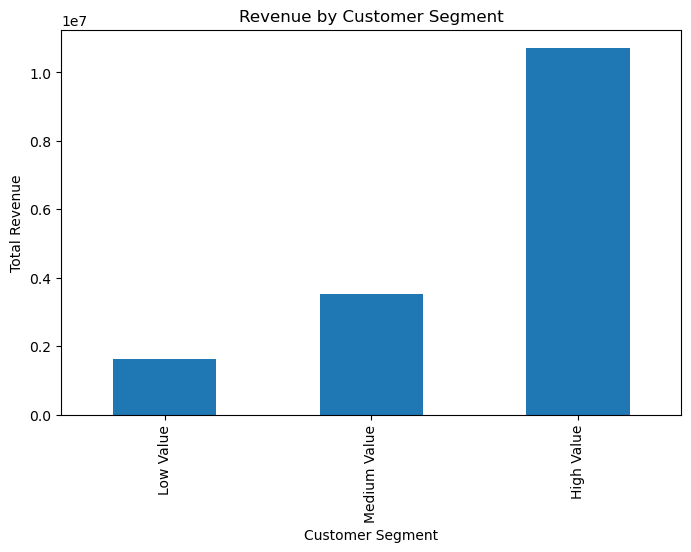

In [25]:
segment_summary["sum"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.show()

# Customer Segment Insight

High Value customers generate the largest share of total revenue despite representing a smaller portion of the customer base.

The company should focus on retaining these customers through loyalty programs, personalized offers, and premium customer experiences.

Low Value customers may be targeted with cross-selling and upselling strategies to increase their contribution.

In [26]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02


In [27]:
monthly_orders = (
    orders.groupby(
        "purchase_month"
    )["order_id"]
    .count()
)

monthly_orders.head()

purchase_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
Freq: M, Name: order_id, dtype: int64

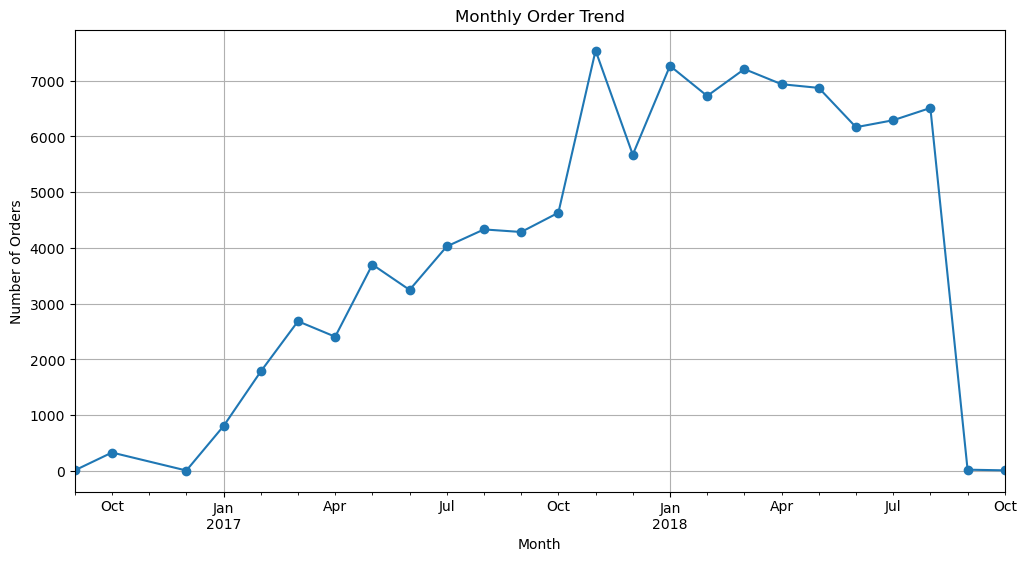

In [28]:
plt.figure(figsize=(12,6))

monthly_orders.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.grid(True)
plt.show()

In [29]:
items_per_order = (
    order_items.groupby(
        "order_id"
    )["order_item_id"]
    .count()
)

items_per_order.describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: order_item_id, dtype: float64

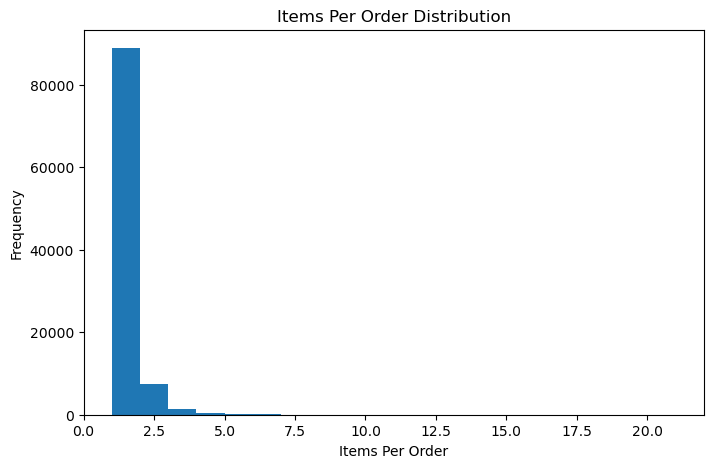

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    items_per_order,
    bins=20
)

plt.title("Items Per Order Distribution")
plt.xlabel("Items Per Order")
plt.ylabel("Frequency")

plt.show()

# Purchasing Behavior Insight

Most customers purchase a small number of items per order, while a smaller group of customers place larger orders.

Order volume changes across months, indicating seasonal purchasing patterns and demand fluctuations.

Understanding these trends helps management improve inventory planning, promotional timing, and demand forecasting.

In [31]:
product_revenue = (
    sales.groupby(
        "product_id"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

product_revenue.head(10)

product_id
bb50f2e236e5eea0100680137654686c    67606.10
d1c427060a0f73f6b889a5c7c61f2ac4    60976.03
6cdd53843498f92890544667809f1595    59093.99
99a4788cb24856965c36a24e339b6058    51071.60
d6160fb7873f184099d9bc95e30376af    50326.18
3dd2a17168ec895c781a9191c1e95ad7    48212.22
aca2eb7d00ea1a7b8ebd4e68314663af    44820.76
5f504b3a1c75b73d6151be81eb05bdc9    41725.81
25c38557cf793876c5abdd5931f922db    40311.95
53b36df67ebb7c41585e8d54d6772e08    39957.93
Name: revenue, dtype: float64

In [32]:
product_volume = (
    sales.groupby(
        "product_id"
    )["order_item_id"]
    .count()
    .sort_values(
        ascending=False
    )
)

product_volume.head(10)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: order_item_id, dtype: int64

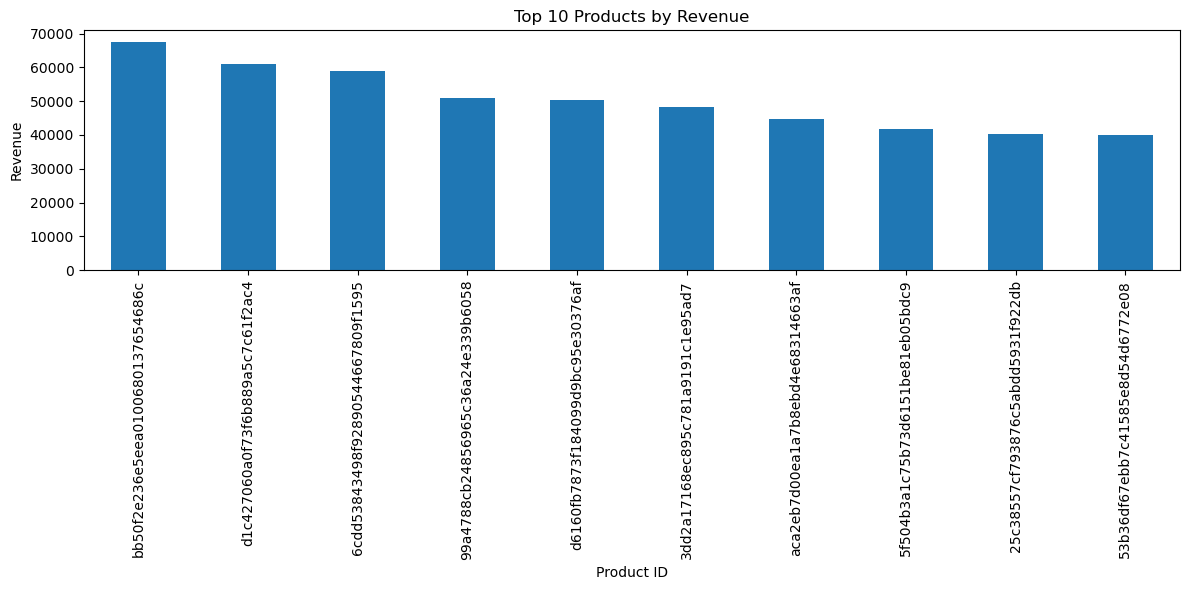

In [33]:
plt.figure(figsize=(12,6))

product_revenue.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

# Product Performance Insight

A small number of products contribute a disproportionately large share of total revenue.

These products should be prioritized for:
- Inventory availability
- Marketing campaigns
- Demand forecasting

Ensuring consistent stock levels for top-performing products can significantly impact overall business performance.

In [34]:
payments = pd.read_csv(
    "Dataset/olist_order_payments_dataset.csv"
)

payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [35]:
payment_summary = (
    payments.groupby(
        "payment_type"
    )["payment_value"]
    .agg(
        ["count", "sum", "mean"]
    )
)

payment_summary

,count,sum,mean
payment_type,,,
boleto,19784,2869361.27,145.034435
credit_card,76795,12542084.19,163.319021
debit_card,1529,217989.79,142.570170
not_defined,3,0.00,0.000000
voucher,5775,379436.87,65.703354


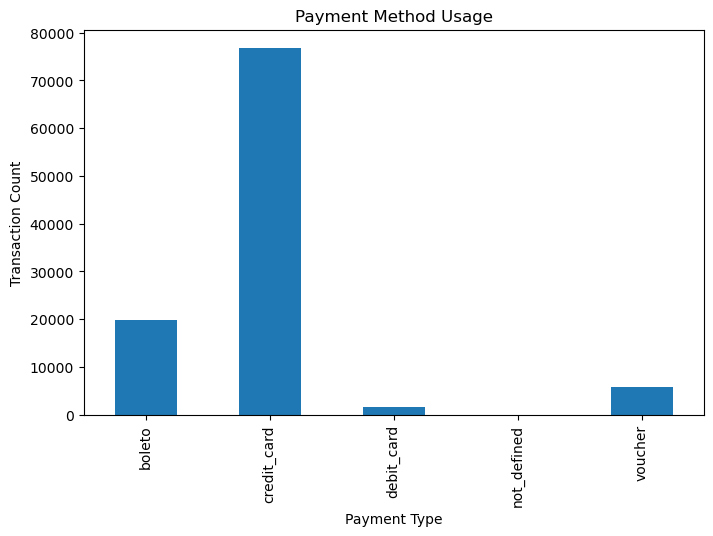

In [36]:
payment_summary["count"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Type")
plt.ylabel("Transaction Count")

plt.show()

# Payment Method Insight

Payment preferences vary significantly across customers.

Understanding preferred payment methods helps the company optimize checkout experiences, reduce payment friction, and improve customer satisfaction.

Popular payment methods should be prioritized for promotional campaigns and payment partnerships.

In [37]:
sellers = pd.read_csv(
    "Dataset/olist_sellers_dataset.csv"
)

seller_sales = sales.merge(
    sellers,
    on="seller_id",
    how="left"
)

seller_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,revenue,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,72.19,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,259.83,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,216.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,25.78,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,218.04,87900,loanda,PR


In [38]:
seller_ranking = (
    seller_sales.groupby(
        "seller_id"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

seller_ranking.head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    249640.70
7c67e1448b00f6e969d365cea6b010ab    239536.44
53243585a1d6dc2643021fd1853d8905    235856.68
4a3ca9315b744ce9f8e9374361493884    235539.96
fa1c13f2614d7b5c4749cbc52fecda94    204084.73
da8622b14eb17ae2831f4ac5b9dab84a    185192.32
7e93a43ef30c4f03f38b393420bc753a    182754.05
1025f0e2d44d7041d6cf58b6550e0bfa    172860.69
7a67c85e85bb2ce8582c35f2203ad736    162648.38
955fee9216a65b617aa5c0531780ce60    160602.68
Name: revenue, dtype: float64

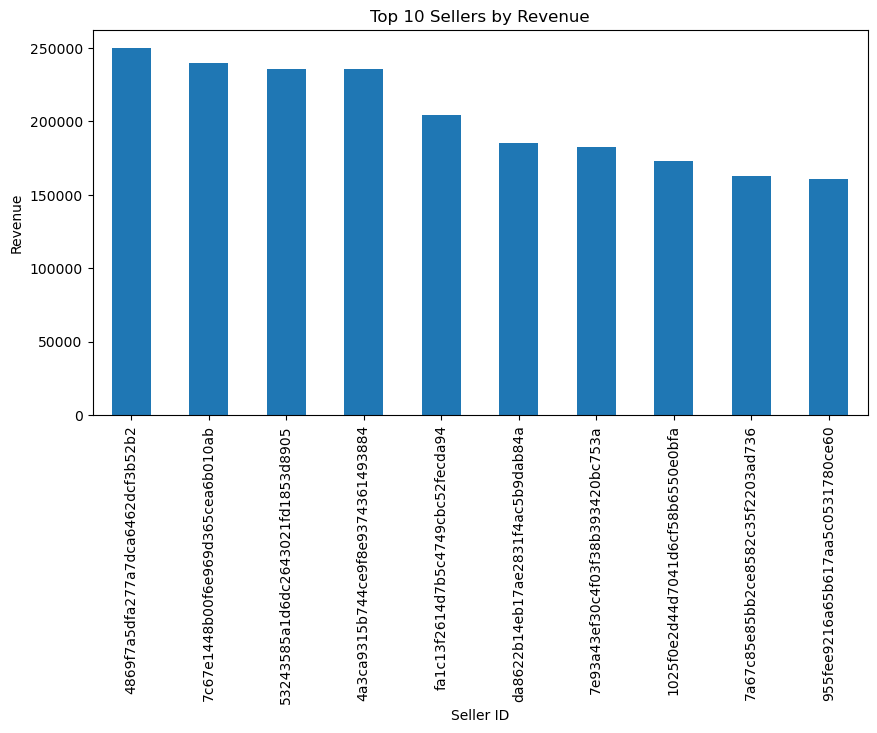

In [39]:
seller_ranking.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")

plt.show()

# Seller Insight

A small number of sellers generate a large portion of total revenue.

The company should maintain strong relationships with top-performing sellers and support them with improved logistics and promotional opportunities.

In [40]:
reviews = pd.read_csv(
    "Dataset/olist_order_reviews_dataset.csv"
)

reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [41]:
review_analysis = sales.merge(
    reviews[
        [
            "order_id",
            "review_score"
        ]
    ],
    on="order_id",
    how="left"
)

review_analysis.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,revenue,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,72.19,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,259.83,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,25.78,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,218.04,5.0


In [42]:
category_reviews = (
    review_analysis.groupby(
        "product_category_name_english"
    )["review_score"]
    .mean()
    .sort_values(
        ascending=False
    )
)

category_reviews.head(10)

product_category_name_english
cds_dvds_musicals                        4.642857
fashion_childrens_clothes                4.500000
books_general_interest                   4.446266
costruction_tools_tools                  4.444444
flowers                                  4.419355
books_imported                           4.400000
books_technical                          4.368421
food_drink                               4.315412
luggage_accessories                      4.315257
small_appliances_home_oven_and_coffee    4.302632
Name: review_score, dtype: float64

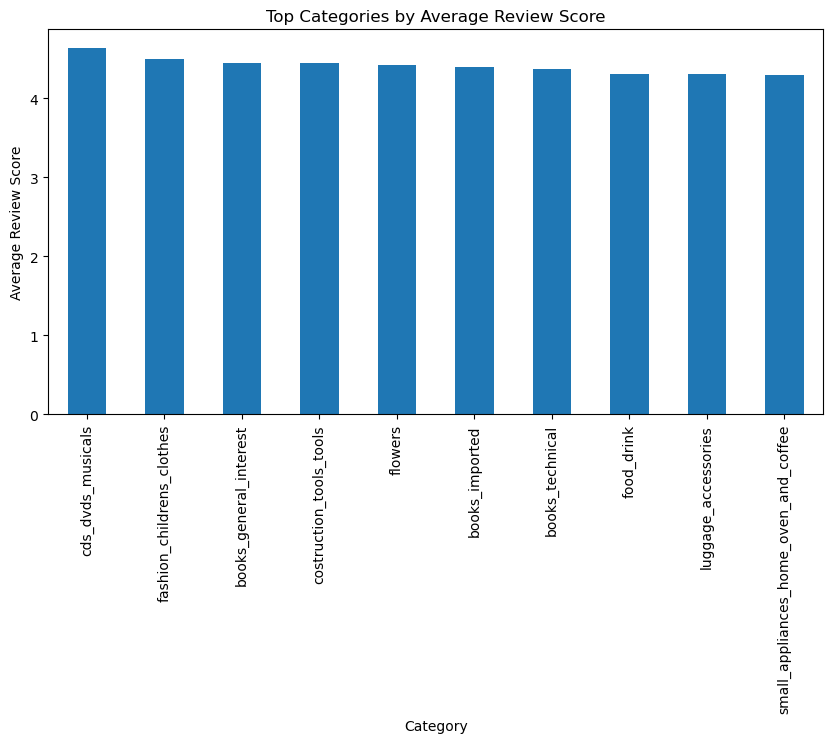

In [43]:
category_reviews.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Categories by Average Review Score")
plt.xlabel("Category")
plt.ylabel("Average Review Score")

plt.show()

# Review Analysis Insight

Higher review scores indicate stronger customer satisfaction.

Categories with lower ratings should be investigated for quality, delivery, or service-related issues.

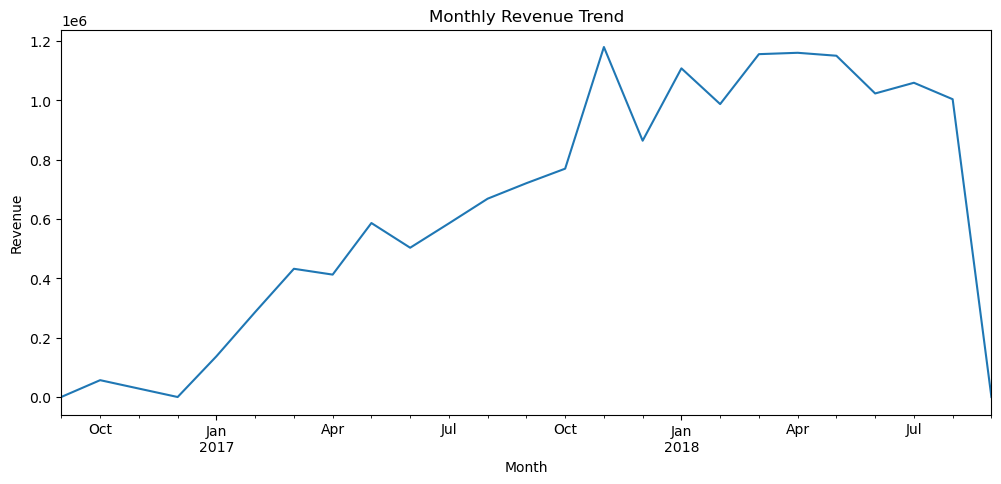

In [44]:
monthly_revenue = (
    sales_region.merge(
        orders[
            [
                "order_id",
                "order_purchase_timestamp"
            ]
        ],
        on="order_id"
    )
)

monthly_revenue["order_purchase_timestamp"] = pd.to_datetime(
    monthly_revenue["order_purchase_timestamp"]
)

monthly_revenue["month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)

revenue_trend = (
    monthly_revenue.groupby(
        "month"
    )["revenue"]
    .sum()
)

revenue_trend.plot(
    figsize=(12,5)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

# Time Trend Insight

Revenue fluctuates across months, indicating seasonal demand patterns.

Understanding seasonality helps improve inventory planning and marketing timing.

In [45]:
repeat_customers = (
    orders.groupby(
        "customer_id"
    )["order_id"]
    .count()
)

repeat_summary = (
    repeat_customers > 1
).value_counts()

repeat_summary

order_id
False    99441
Name: count, dtype: int64

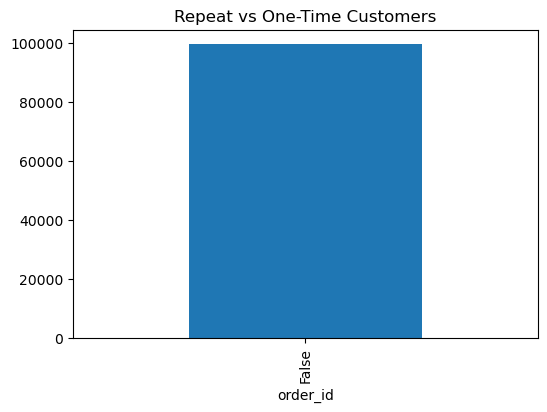

In [46]:
repeat_summary.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Repeat vs One-Time Customers")
plt.show()

# Customer Retention Insight

Repeat customers are valuable because they generate recurring revenue.

Retention programs should focus on increasing the number of returning customers.

In [48]:
print("Customers Missing Values")
print(customers.isnull().sum())

print("\nOrders Missing Values")
print(orders.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())

print("\nDuplicates")
print("Customers:", customers.duplicated().sum())
print("Orders:", orders.duplicated().sum())
print("Products:", products.duplicated().sum())

Customers Missing Values
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders Missing Values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
purchase_month                      0
dtype: int64

Products Missing Values
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Duplicates
Customers: 0
Orders: 0
Products: 0


# Data Quality Summary

Missing values were identified primarily in delivery-related fields.

Duplicate checks were performed and documented.

Data types were reviewed and corrected where necessary.

In [49]:
print("Orders Rows:", len(orders))
print("Sales Rows:", len(sales))
print("Sales Region Rows:", len(sales_region))
print("Seller Sales Rows:", len(seller_sales))

Orders Rows: 99441
Sales Rows: 112650
Sales Region Rows: 112650
Seller Sales Rows: 112650


# Merge Validation Summary

Multiple datasets were successfully merged using common keys.

Row counts were checked after each merge to ensure data integrity.

No major merge failures were identified.

# Final Conclusion

The analysis identified key revenue-generating categories, top-performing sellers, important geographic markets, customer purchasing patterns, payment preferences, and seasonal sales trends.

Key Recommendations:

1. Invest more in high-revenue product categories.
2. Strengthen relationships with top sellers.
3. Improve retention of repeat customers.
4. Focus marketing efforts on high-performing regions.
5. Monitor low-rated categories for quality improvements.

These insights can help management make data-driven business decisions and improve overall performance.